# Health Misinformation Survey Analysis

This notebook explores how social media behavior relates to trust in health information among student respondents.

We will:
- clean and prepare survey data
- summarize key demographic and behavioral patterns
- visualize trust distributions and relationships
- extract quick, decision-friendly insights

In [10]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Load Data
The code below checks common file locations and loads the first match.

In [11]:
candidate_paths = [
    Path("HealthMisinformation.csv"),
    Path(r"c:/Users/josep/OneDrive/Documents/GW 2026/Foundations of Research PUBH 2140/HealthMisinformation.csv")
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find HealthMisinformation.csv. Place it in the notebook folder or update candidate_paths.")

df_raw = pd.read_csv(csv_path)
print(f"Loaded file: {csv_path}")
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")
df_raw.head()

Loaded file: c:\Users\josep\OneDrive\Documents\GW 2026\Foundations of Research PUBH 2140\HealthMisinformation.csv
Rows: 12, Columns: 41


,Timestamp,Total score,Do you consent to participate?,Do you consent to participate? [Score],Do you consent to participate? [Feedback],What is your age range?,What is your age range? [Score],What is your age range? [Feedback],What is your gender?,What is your gender? [Score],What is your gender? [Feedback],What is your academic year,What is your academic year [Score],What is your academic year [Feedback],How often do you use social media?,How often do you use social media? [Score],How often do you use social media? [Feedback],Which platforms do you use most frequently?,Which platforms do you use most frequently? [Score],Which platforms do you use most frequently? [Feedback],How often do you encounter health-related content on social media?,How often do you encounter health-related content on social media? [Score],How often do you encounter health-related content on social media? [Feedback],I trust doctors and healthcare professionals.,I trust doctors and healthcare professionals. [Score],I trust doctors and healthcare professionals. [Feedback],"I trust public health agencies (e.g., CDC, WHO.)","I trust public health agencies (e.g., CDC, WHO.) [Score]","I trust public health agencies (e.g., CDC, WHO.) [Feedback]",I trust hospitals and healthcare systems.,I trust hospitals and healthcare systems. [Score],I trust hospitals and healthcare systems. [Feedback],I trust government leadership in making health-related decisions.,I trust government leadership in making health-related decisions. [Score],I trust government leadership in making health-related decisions. [Feedback],Information from health professionals is more reliable than social media.,Information from health professionals is more reliable than social media. [Score],Information from health professionals is more reliable than social media. [Feedback],"In your own words, how does social media influence your trust in health information?","In your own words, how does social media influence your trust in health information? [Score]","In your own words, how does social media influence your trust in health information? [Feedback]"
0,2026/03/26 12:36:20 PM AST,0.00 / 0,Yes - Continue to survey,-- / 0,NaN,24+,-- / 0,NaN,Male,-- / 0,NaN,Senior,-- / 0,NaN,1-2 hours,-- / 0,NaN,Tiktok;YouTube;Facebook,-- / 0,NaN,Often,-- / 0,NaN,5,-- / 0,NaN,2,-- / 0,NaN,4,-- / 0,NaN,3,-- / 0,NaN,4,-- / 0,NaN,NaN,-- / 0,NaN
1,2026/03/26 12:48:35 PM AST,0.00 / 0,Yes - Continue to survey,-- / 0,NaN,18-20,-- / 0,NaN,Male,-- / 0,NaN,Freshman,-- / 0,NaN,1-2 hours,-- / 0,NaN,Tiktok;Instagram;YouTube,-- / 0,NaN,Often,-- / 0,NaN,5,-- / 0,NaN,5,-- / 0,NaN,5,-- / 0,NaN,2,-- / 0,NaN,5,-- / 0,NaN,Social Media give a microphone to any famous p...,-- / 0,NaN
2,2026/03/26 12:50:41 PM AST,0.00 / 0,Yes - Continue to survey,-- / 0,NaN,18-20,-- / 0,NaN,Male,-- / 0,NaN,Sophomore,-- / 0,NaN,3-4 hours,-- / 0,NaN,Tiktok;Instagram;YouTube,-- / 0,NaN,Sometimes,-- / 0,NaN,5,-- / 0,NaN,4,-- / 0,NaN,2,-- / 0,NaN,1,-- / 0,NaN,5,-- / 0,NaN,NaN,-- / 0,NaN
3,2026/03/26 1:36:57 PM AST,0.00 / 0,Yes - Continue to survey,-- / 0,NaN,18-20,-- / 0,NaN,Female,-- / 0,NaN,Sophomore,-- / 0,NaN,Less than 1 hour per day,-- / 0,NaN,Tiktok,-- / 0,NaN,Often,-- / 0,NaN,4,-- / 0,NaN,3,-- / 0,NaN,2,-- / 0,NaN,1,-- / 0,NaN,4,-- / 0,NaN,It doesn't. I always find myself very skeptica...,-- / 0,NaN
4,2026/03/26 1:37:34 PM AST,0.00 / 0,Yes - Continue to survey,-- / 0,NaN,21-23,-- / 0,NaN,Male,-- / 0,NaN,Junior,-- / 0,NaN,3-4 hours,-- / 0,NaN,Tiktok;Instagram,-- / 0,NaN,Sometimes,-- / 0,NaN,4,-- / 0,NaN,4,-- / 0,NaN,4,-- / 0,NaN,2,-- / 0,NaN,4,-- / 0,NaN,NaN,-- / 0,NaN


## 2. Prepare Analysis Dataset
The survey export includes score/feedback helper columns. Here we retain core analytical variables and convert trust responses to numeric Likert values (1-5).

In [12]:
df = df_raw.copy()

selected_cols = {
    "What is your age range?": "age_range",
    "What is your gender?": "gender",
    "What is your academic year": "academic_year",
    "How often do you use social media?": "social_media_use",
    "Which platforms do you use most frequently?": "platforms",
    "How often do you encounter health-related content on social media?": "health_content_frequency",
    "I trust doctors and healthcare professionals.": "trust_doctors",
    "I trust public health agencies (e.g., CDC, WHO.)": "trust_public_health",
    "I trust hospitals and healthcare systems. ": "trust_hospitals",
    "I trust government leadership in making health-related decisions.": "trust_government",
    "Information from health professionals is more reliable than social media. ": "professionals_more_reliable",
    "In your own words, how does social media influence your trust in health information?  " : "open_response"
}

missing = [c for c in selected_cols if c not in df.columns]
if missing:
    raise KeyError(f"Missing expected columns: {missing}")

analysis = df[list(selected_cols.keys())].rename(columns=selected_cols)

trust_cols = [
    "trust_doctors",
    "trust_public_health",
    "trust_hospitals",
    "trust_government",
    "professionals_more_reliable"
]

for c in trust_cols:
    analysis[c] = pd.to_numeric(analysis[c], errors="coerce")

analysis["avg_trust"] = analysis[trust_cols].mean(axis=1)
analysis.head()

,age_range,gender,academic_year,social_media_use,platforms,health_content_frequency,trust_doctors,trust_public_health,trust_hospitals,trust_government,professionals_more_reliable,open_response,avg_trust
0,24+,Male,Senior,1-2 hours,Tiktok;YouTube;Facebook,Often,5,2,4,3,4,NaN,3.6
1,18-20,Male,Freshman,1-2 hours,Tiktok;Instagram;YouTube,Often,5,5,5,2,5,Social Media give a microphone to any famous p...,4.4
2,18-20,Male,Sophomore,3-4 hours,Tiktok;Instagram;YouTube,Sometimes,5,4,2,1,5,NaN,3.4
3,18-20,Female,Sophomore,Less than 1 hour per day,Tiktok,Often,4,3,2,1,4,It doesn't. I always find myself very skeptica...,2.8
4,21-23,Male,Junior,3-4 hours,Tiktok;Instagram,Sometimes,4,4,4,2,4,NaN,3.6


## 3. Quick Profile of Respondents
This view shows who responded and how much they use social media.

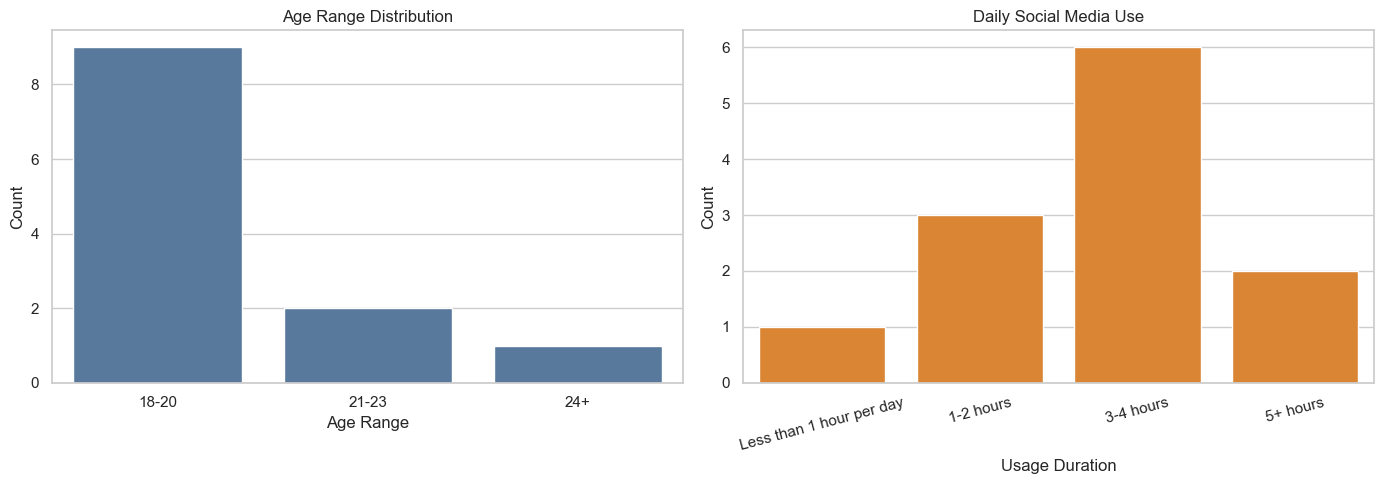

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

age_order = analysis["age_range"].value_counts().index
sns.countplot(data=analysis, x="age_range", order=age_order, ax=axes[0], color="#4C78A8")
axes[0].set_title("Age Range Distribution")
axes[0].set_xlabel("Age Range")
axes[0].set_ylabel("Count")

use_order = ["Less than 1 hour per day", "1-2 hours", "3-4 hours", "5+ hours"]
sns.countplot(data=analysis, x="social_media_use", order=use_order, ax=axes[1], color="#F58518")
axes[1].set_title("Daily Social Media Use")
axes[1].set_xlabel("Usage Duration")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Insight
A quick profile often reveals whether interpretations should be treated as representative or exploratory. In small samples, strong trends are useful but should be validated with larger follow-up data.

## 4. Platform Popularity (Multi-Select Responses)
Because platform choices are stored as semicolon-separated selections, we split and count each platform mention.

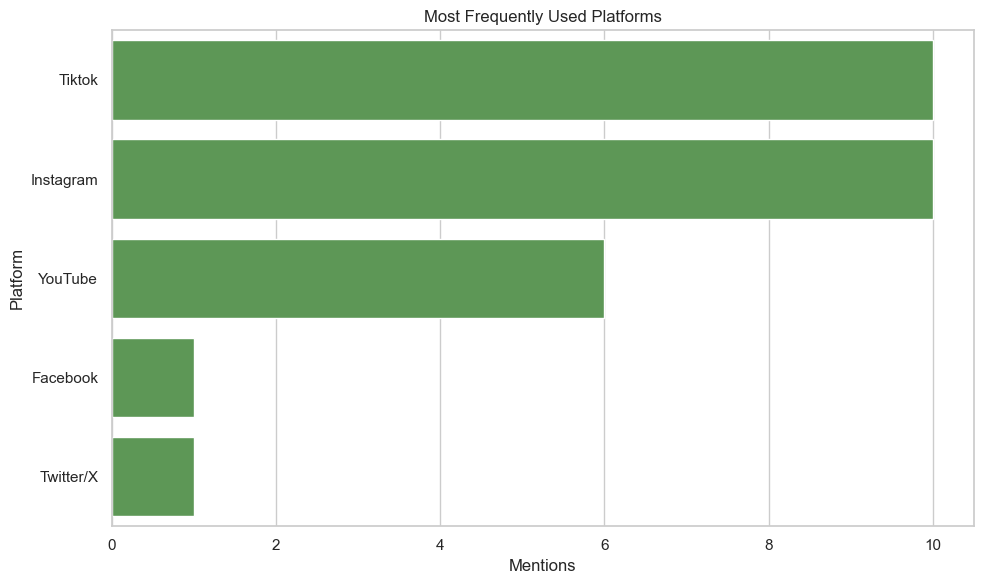

platforms
Tiktok       10
Instagram    10
YouTube       6
Facebook      1
Twitter/X     1
Name: count, dtype: int64

In [14]:
platform_counts = (
    analysis["platforms"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
    .value_counts()
)

sns.barplot(x=platform_counts.values, y=platform_counts.index, color="#54A24B")
plt.title("Most Frequently Used Platforms")
plt.xlabel("Mentions")
plt.ylabel("Platform")
plt.tight_layout()
plt.show()

platform_counts

### Insight
Platform concentration matters for intervention design. If most users cluster on one or two channels, targeted health communication campaigns can be more efficient than broad multi-platform messaging.

## 5. Trust by Source Type
This chart compares average trust scores across institutions and information sources.

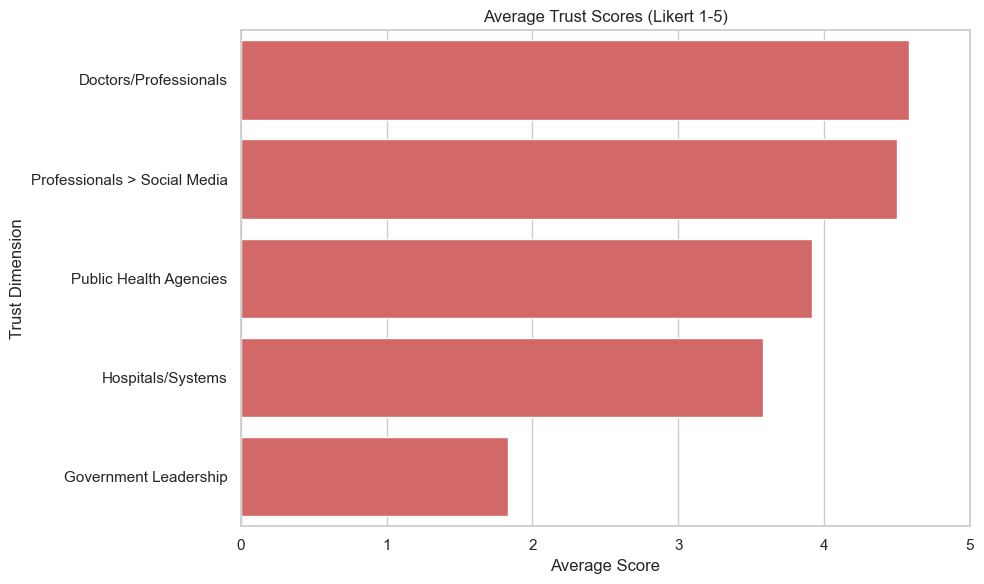

Doctors/Professionals           4.583333
Professionals > Social Media    4.500000
Public Health Agencies          3.916667
Hospitals/Systems               3.583333
Government Leadership           1.833333
dtype: float64

In [15]:
trust_means = analysis[trust_cols].mean().sort_values(ascending=False)

label_map = {
    "trust_doctors": "Doctors/Professionals",
    "trust_public_health": "Public Health Agencies",
    "trust_hospitals": "Hospitals/Systems",
    "trust_government": "Government Leadership",
    "professionals_more_reliable": "Professionals > Social Media"
}

plot_data = trust_means.rename(index=label_map)

sns.barplot(x=plot_data.values, y=plot_data.index, color="#E45756")
plt.title("Average Trust Scores (Likert 1-5)")
plt.xlabel("Average Score")
plt.ylabel("Trust Dimension")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

plot_data

### Insight
A common pattern in misinformation contexts is lower trust in government than in clinicians or formal healthcare institutions. This can guide who should be the messenger in public health campaigns.

## 6. Correlation Heatmap of Trust Variables
Correlation helps show whether trust dimensions move together (e.g., trusting doctors and agencies simultaneously).

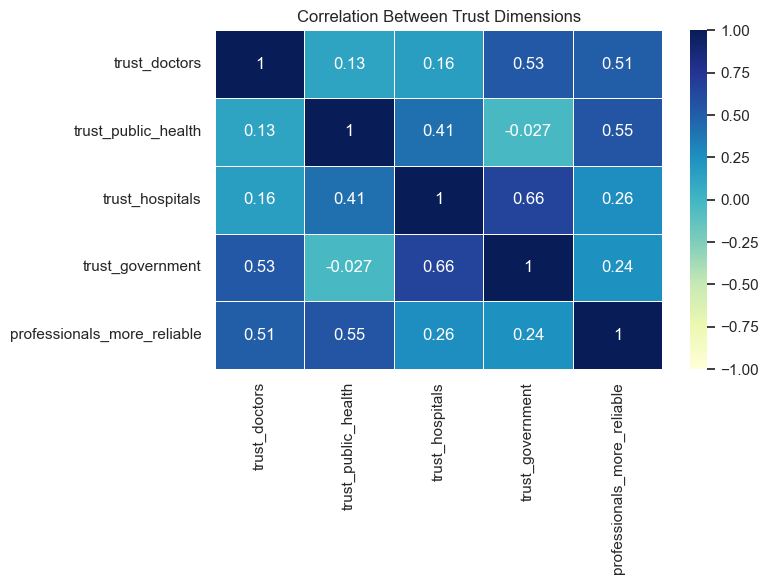

In [16]:
corr = analysis[trust_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="YlGnBu", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Between Trust Dimensions")
plt.tight_layout()
plt.show()

### Insight
Higher positive correlations suggest that trust can function as a broader attitude rather than isolated beliefs. If one trust domain is improved, others may improve with it.

## 7. Exposure vs Overall Trust
This visualization checks whether seeing health-related content more frequently is associated with higher or lower overall trust.

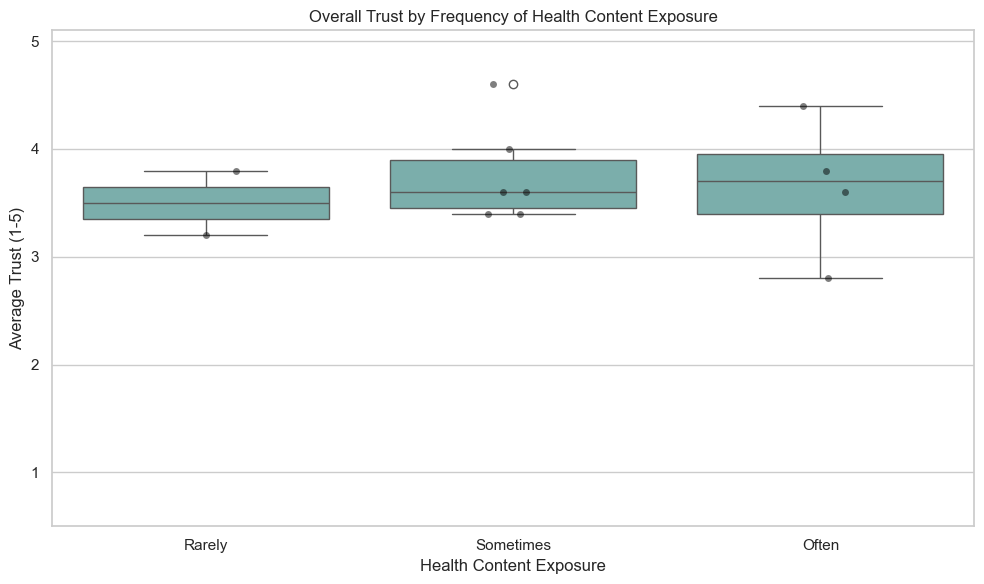

,count,mean,std
health_content_frequency,,,
Often,4,3.650000,0.660808
Rarely,2,3.500000,0.424264
Sometimes,6,3.766667,0.463321


In [17]:
exposure_order = ["Rarely", "Sometimes", "Often"]

sns.boxplot(
    data=analysis,
    x="health_content_frequency",
    y="avg_trust",
    order=exposure_order,
    color="#72B7B2"
)
sns.stripplot(
    data=analysis,
    x="health_content_frequency",
    y="avg_trust",
    order=exposure_order,
    color="black",
    alpha=0.5,
    size=5
)

plt.title("Overall Trust by Frequency of Health Content Exposure")
plt.xlabel("Health Content Exposure")
plt.ylabel("Average Trust (1-5)")
plt.ylim(0.5, 5.1)
plt.tight_layout()
plt.show()

analysis.groupby("health_content_frequency")["avg_trust"].agg(["count", "mean", "std"]).sort_index()

## 8. Open-Response Snapshot
Qualitative responses help explain *why* numeric trust patterns appear.

In [18]:
responses = analysis["open_response"].dropna().str.strip()
responses = responses[responses != ""]

print(f"Non-empty responses: {len(responses)}")
responses.head(10)

Non-empty responses: 6


1     Social Media give a microphone to any famous p...
3     It doesn't. I always find myself very skeptica...
7     It often sells me things that influence how I ...
8     I find that social media tend to spread misinf...
9     I don't usually trust the health information t...
11                                            sometimes
Name: open_response, dtype: str

## 9. Key Takeaways
1. **Trust is not uniform across institutions**; differences in messenger credibility are visible even in a small sample.
2. **Platform concentration provides intervention leverage**; focusing on dominant channels can improve campaign efficiency.
3. **Health-content exposure may shape trust**, but sample size is limited, so this is best treated as exploratory evidence.
4. **Mixed-method interpretation is strongest**: pair quantitative scores with open responses to understand mechanisms behind trust and skepticism.